[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/haohanchen/POLI3148_2026Spring_TextAnalysis/blob/main/lecture/session_3_sentiment_classification/session_3_sentiment_classification.ipynb)

# Session 3: Sentiment Analysis and Text Classification

**POLI3148 -- Data Science in Politics and Public Administration (HKU)**

---

In this session, we move from describing text content (word frequencies, topics) to **labeling** documents at scale. We cover two complementary approaches:

1. **Dictionary-based sentiment analysis** -- score each document's positivity/negativity using a pre-built lexicon (no training data required).
2. **Machine learning text classification** -- train a supervised model to assign binary labels (e.g., "aggressive" vs. "non-aggressive") based on labeled examples.

These are the workhorses of traditional text analysis. They require deliberate preprocessing and feature engineering -- a contrast to the LLM-based approaches we will explore in Sessions 4--5, where a natural language prompt replaces most of this pipeline.

**Data:** MoFA Press Conference Corpus (2002--2025), ~35,000 Q&A exchanges between journalists and Chinese Ministry of Foreign Affairs spokespeople.

## Setup

In [61]:
!pip install -q vaderSentiment scikit-learn spacy openpyxl seaborn
!python -m spacy download en_core_web_sm -q

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 102.5 MB/s eta 0:00:0000:0100:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


In [62]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import spacy
import warnings
warnings.filterwarnings("ignore")

from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn import metrics

# Plotting defaults
plt.rcParams["figure.dpi"] = 120
plt.rcParams["font.size"] = 11
sns.set_style("whitegrid")

In [63]:
# Load the MoFA Press Conference corpus
# Load data from GitHub
DATA_URL = "https://github.com/haohanchen/POLI3148_2026Spring_TextAnalysis/raw/main/data/CMFA_PressCon_v6.xlsx"
df = pd.read_excel(DATA_URL)
print(f"Dataset shape: {df.shape[0]} rows, {df.shape[1]} columns")
df.head(3)

Dataset shape: 35346 rows, 24 columns


,id_orig,id_split,id,link,spokesperson,day,month,year,date,question,...,q_loc,q_per,q_org,q_misc,a_loc,a_per,a_org,a_misc,q_sentiment,a_sentiment
0,1,1,1,http://web.archive.org/web/20030907084940/http...,Zhang Qiyue,15,October,2002,2002-10-15 00:00:00,How many Hong Kong and Taiwan people were inju...,...,Taiwan; Mainland; Indonesia; Hong Kong; Bali I...,-,-,Chinese,Taiwan; Mainland; Macao; Indonesia; Hong Kong;...,-,Government,Indonesian; Chinese,0.939969,2.354945
1,2,2,2,http://web.archive.org/web/20030907084940/http...,Zhang Qiyue,15,October,2002,2002-10-15 00:00:00,"Today, five Japanese who were kidnapped by the...",...,North Korea; China,-,-,-,Japan; DPRK; China,-,-,Japan-DPRK,2.474082,5.112201
2,3,3,3,http://web.archive.org/web/20030907084940/http...,Zhang Qiyue,15,October,2002,2002-10-15 00:00:00,Recently Nepal formed an interim government. H...,...,Nepal,-,-,-,Nepal; China,-,Nepali Interim Government,Nepali; Five Principles of Peaceful Coexistenc...,3.039821,4.926227


---
## Part A: Dictionary-Based Sentiment Analysis

### A.1 How Sentiment Dictionaries Work

Sentiment analysis assigns a **positivity/negativity score** to a piece of text. Dictionary-based (or lexicon-based) methods work by:

1. Looking up each word in a pre-built dictionary that maps words to sentiment scores.
2. Combining word-level scores into a document-level score using rules.

**VADER** (Valence Aware Dictionary and sEntiment Reasoner) is a popular rule-based sentiment tool designed for social media text but widely used in political science. It assigns each word a valence score and applies rules for:

- **Negation** ("not good" flips the sign)
- **Intensifiers** ("extremely" amplifies the score)
- **Capitalization and punctuation** ("GREAT!!!" scores higher than "great")

VADER returns four scores for each text: `pos`, `neg`, `neu` (proportions summing to 1), and a `compound` score (normalized to [-1, +1]).

VADER produces four scores for each text:

| Score | Meaning |
|-------|---------|
| **pos** | Proportion of text that is positive (0 to 1) |
| **neg** | Proportion of text that is negative (0 to 1) |
| **neu** | Proportion of text that is neutral (0 to 1) |
| **compound** | Overall sentiment, normalized to [-1, +1] |

The **compound** score is the most commonly used. It is computed by summing the valence scores of each word in the lexicon, adjusting for rules (negation, intensifiers, punctuation), and then normalizing to a range of -1 (most negative) to +1 (most positive). A compound score > 0.05 is typically considered positive, < -0.05 negative, and in between neutral.


In [64]:
# Initialize VADER
analyzer = SentimentIntensityAnalyzer()

# Demo on three example sentences
examples = [
    "China welcomes the initiative and looks forward to cooperation.",
    "China strongly condemns this gross interference in internal affairs.",
    "The spokesperson held a regular press conference on Tuesday."
]

for sent in examples:
    scores = analyzer.polarity_scores(sent)
    print(f"Text: {sent}")
    print(f"  compound={scores['compound']:.3f}  pos={scores['pos']:.3f}  neg={scores['neg']:.3f}  neu={scores['neu']:.3f}")
    print()

Text: China welcomes the initiative and looks forward to cooperation.
  compound=0.402  pos=0.252  neg=0.000  neu=0.748

Text: China strongly condemns this gross interference in internal affairs.
  compound=-0.649  pos=0.145  neg=0.441  neu=0.414

Text: The spokesperson held a regular press conference on Tuesday.
  compound=0.000  pos=0.000  neg=0.000  neu=1.000



Notice how VADER correctly identifies the positive, negative, and neutral sentences. The `compound` score is the most useful single number: +1 is maximally positive, -1 is maximally negative.

### A.2 Apply VADER to MoFA Questions

In [65]:
# Apply VADER to all questions
df = df.dropna(subset=["question"]).copy()
print(f"Rows with valid questions: {len(df)}")

# Compute VADER scores for each question (compound, positive, negative, neutral)
vader_scores = df["question"].apply(lambda x: analyzer.polarity_scores(str(x)))
df["vader_compound"] = vader_scores.apply(lambda x: x["compound"])
df["vader_pos"] = vader_scores.apply(lambda x: x["pos"])
df["vader_neg"] = vader_scores.apply(lambda x: x["neg"])
df["vader_neu"] = vader_scores.apply(lambda x: x["neu"])

print(f"\nVADER compound score summary:")
print(df["vader_compound"].describe())


Rows with valid questions: 35346

VADER compound score summary:
count    35346.000000
mean         0.086517
std          0.470706
min         -0.993800
25%         -0.202300
50%          0.000000
75%          0.440400
max          0.995700
Name: vader_compound, dtype: float64


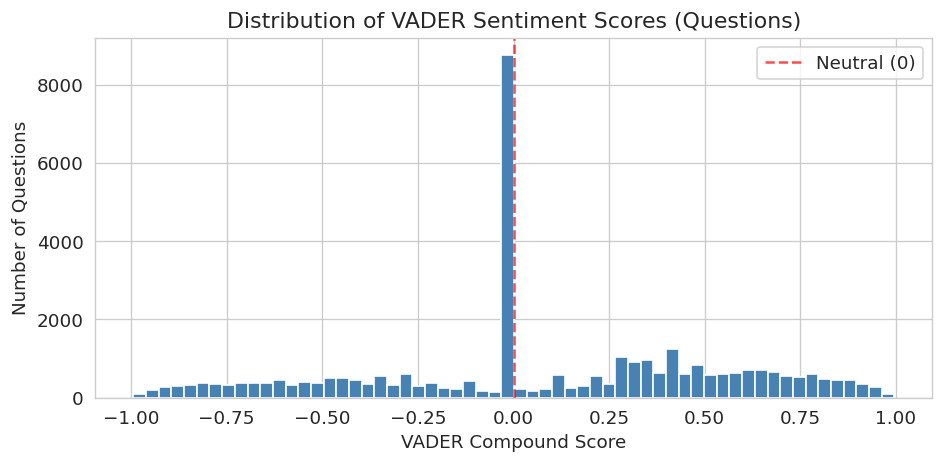

In [66]:
# Distribution of VADER compound scores
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(df["vader_compound"], bins=60, color="steelblue", edgecolor="white")
ax.set_xlabel("VADER Compound Score")
ax.set_ylabel("Number of Questions")
ax.set_title("Distribution of VADER Sentiment Scores (Questions)")
ax.axvline(0, color="red", linestyle="--", alpha=0.7, label="Neutral (0)")
ax.legend()
plt.tight_layout()
plt.show()

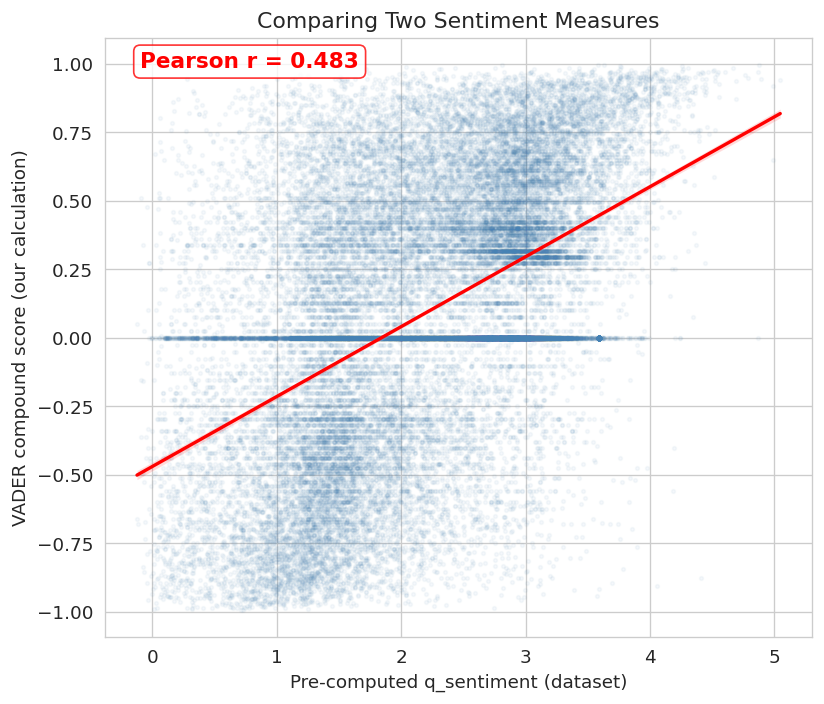

In [67]:
# Compare VADER scores with the dataset's pre-computed q_sentiment column
import numpy as np
from scipy import stats

df_compare = df.dropna(subset=["q_sentiment"]).copy()

# Compute correlation
corr = df_compare["q_sentiment"].corr(df_compare["vader_compound"])

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df_compare["q_sentiment"], df_compare["vader_compound"], alpha=0.05, s=5, color="steelblue")

# Add linear regression line with 99% CI
sns.regplot(x="q_sentiment", y="vader_compound", data=df_compare,
            scatter=False, ax=ax, color="red", line_kws={"linewidth": 2}, ci=99)

# Annotate with correlation
ax.annotate(f"Pearson r = {corr:.3f}", xy=(0.05, 0.95), xycoords="axes fraction",
            fontsize=13, fontweight="bold", color="red",
            bbox=dict(boxstyle="round,pad=0.3", facecolor="white", edgecolor="red", alpha=0.8))

ax.set_xlabel("Pre-computed q_sentiment (dataset)")
ax.set_ylabel("VADER compound score (our calculation)")
ax.set_title("Comparing Two Sentiment Measures")
plt.tight_layout()
plt.show()


**Discussion:** The two sentiment measures are correlated but far from identical. The dataset's `q_sentiment` column was computed with a different tool (TextBlob or Flair). This is a general lesson: **different sentiment tools can disagree**, because they use different dictionaries, different aggregation rules, and different underlying models. Always report which tool you used and consider validating against human judgments.

### A.3 Sentiment Trends

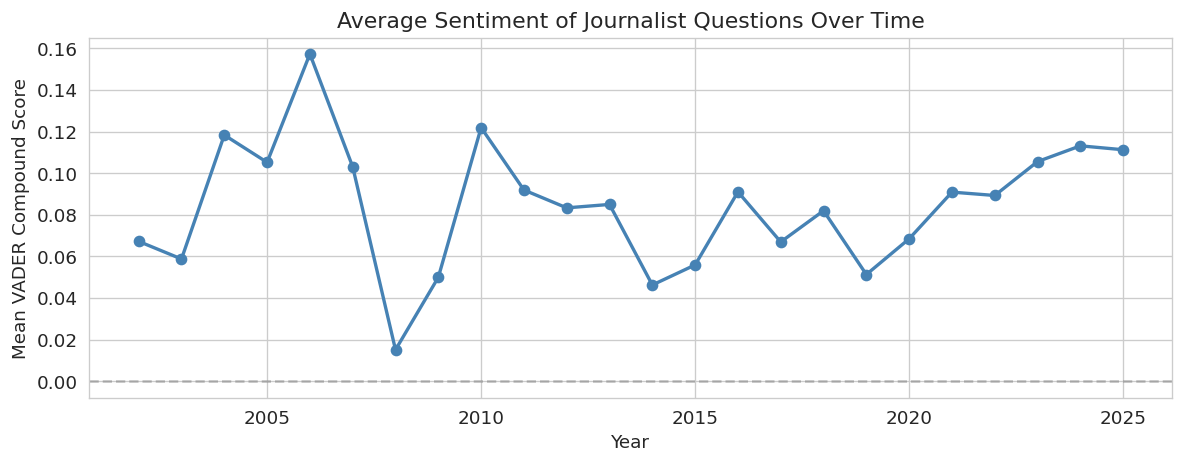

In [68]:
# Average VADER sentiment of questions by year
yearly = df.groupby("year")["vader_compound"].mean()

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(yearly.index, yearly.values, marker="o", color="steelblue", linewidth=2)
ax.axhline(0, color="gray", linestyle="--", alpha=0.5)
ax.set_xlabel("Year")
ax.set_ylabel("Mean VADER Compound Score")
ax.set_title("Average Sentiment of Journalist Questions Over Time")
plt.tight_layout()
plt.show()

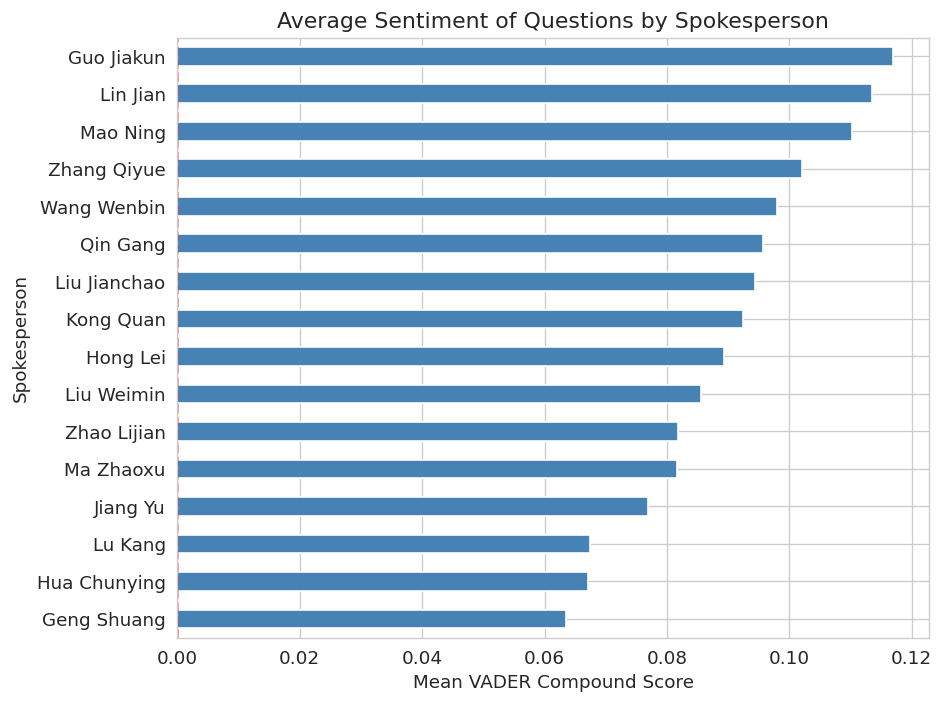

Spokesperson facing the most negative questions: Geng Shuang (mean=0.064)


In [69]:
# Average VADER sentiment by spokesperson (exclude unidentified)
df_valid_sp = df[~df["spokesperson"].isin(["missing", "-"])]
by_spokesperson = df_valid_sp.groupby("spokesperson")["vader_compound"].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 6))
by_spokesperson.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Mean VADER Compound Score")
ax.set_ylabel("Spokesperson")
ax.set_title("Average Sentiment of Questions by Spokesperson")
ax.axvline(0, color="red", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()

print(f"Spokesperson facing the most negative questions: {by_spokesperson.index[0]} (mean={by_spokesperson.iloc[0]:.3f})")


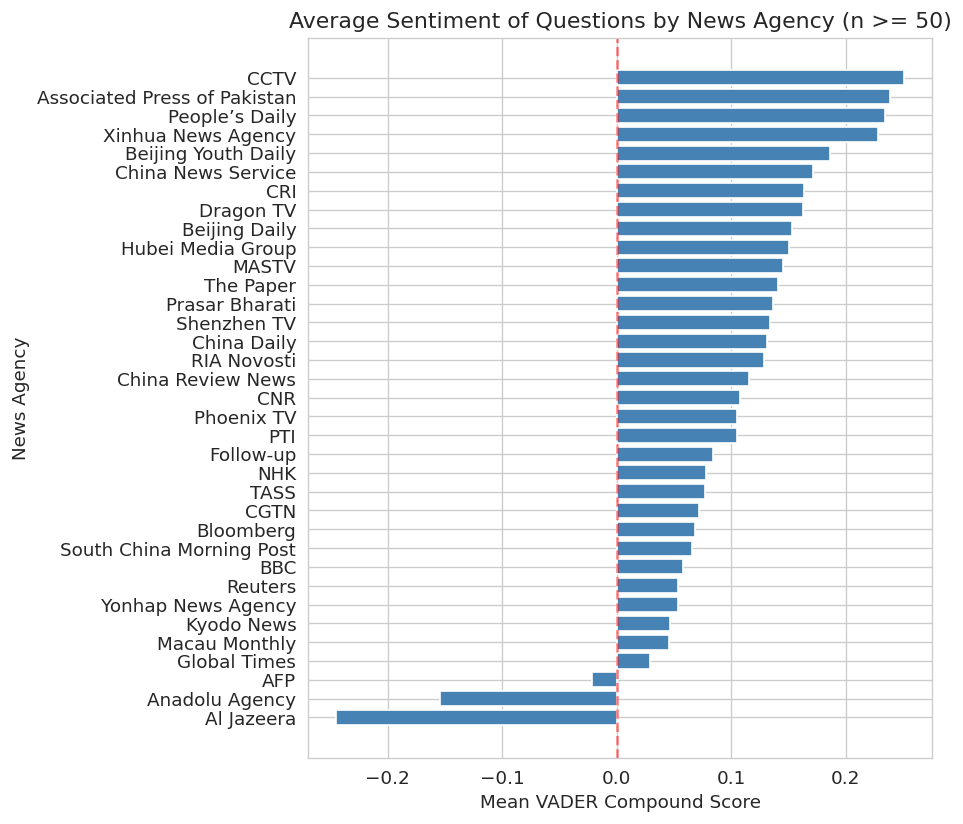

In [70]:
# Average VADER sentiment by asker (news agency), excluding unidentified
df_valid_asker = df[~df["who_asked"].isin(["-", "missing"])]
by_asker = df_valid_asker.groupby("who_asked")["vader_compound"].agg(["mean", "count"])
by_asker = by_asker[by_asker["count"] >= 50]  # only agencies with 50+ questions (HC note: You can change this to include more media)
by_asker = by_asker.sort_values("mean")

fig, ax = plt.subplots(figsize=(8, 7))
ax.barh(by_asker.index, by_asker["mean"], color="steelblue", edgecolor="white")
ax.set_xlabel("Mean VADER Compound Score")
ax.set_ylabel("News Agency")
ax.set_title("Average Sentiment of Questions by News Agency (n >= 50)")
ax.axvline(0, color="red", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


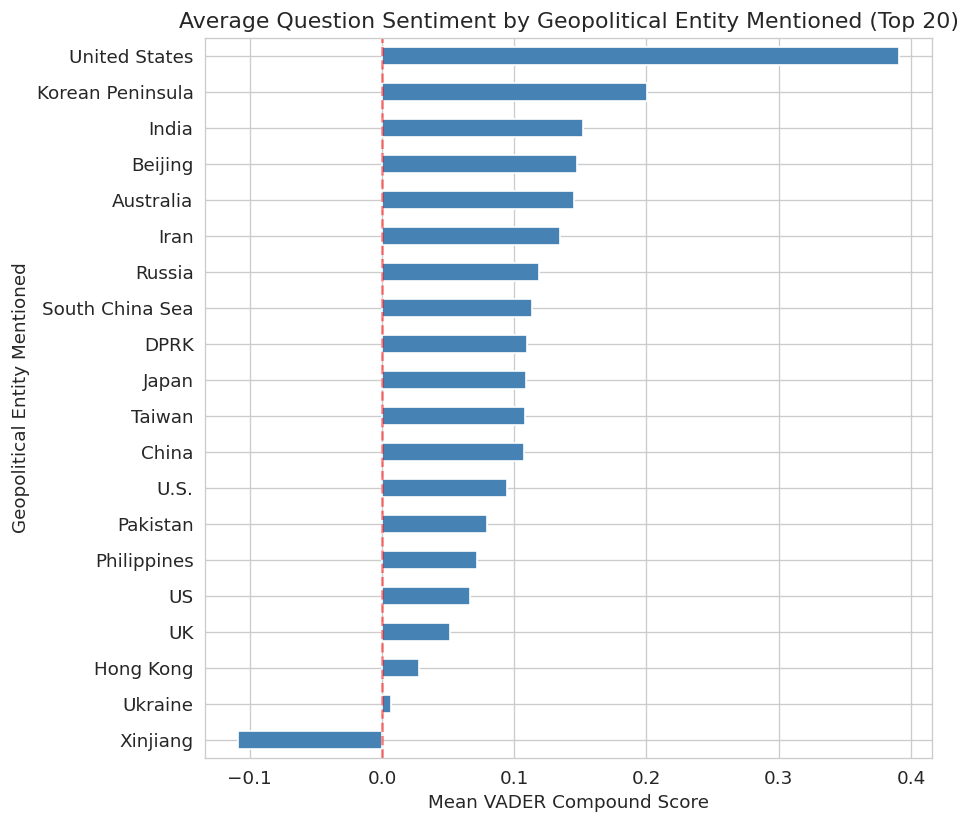

In [71]:
# Average sentiment of questions mentioning different countries/regions
# Explode the q_loc column (semicolon-separated) to get one row per location per question
df_loc = df[df["q_loc"] != "-"].copy()
df_loc["location"] = df_loc["q_loc"].str.split("; ")
df_loc = df_loc.explode("location")

# Count and filter to top 20 most-mentioned locations
top_locs = df_loc["location"].value_counts().head(20).index.tolist()
df_loc_top = df_loc[df_loc["location"].isin(top_locs)]

by_location = df_loc_top.groupby("location")["vader_compound"].mean().sort_values()

fig, ax = plt.subplots(figsize=(8, 7))
by_location.plot(kind="barh", ax=ax, color="steelblue", edgecolor="white")
ax.set_xlabel("Mean VADER Compound Score")
ax.set_ylabel("Geopolitical Entity Mentioned")
ax.set_title("Average Question Sentiment by Geopolitical Entity Mentioned (Top 20)")
ax.axvline(0, color="red", linestyle="--", alpha=0.5)
plt.tight_layout()
plt.show()


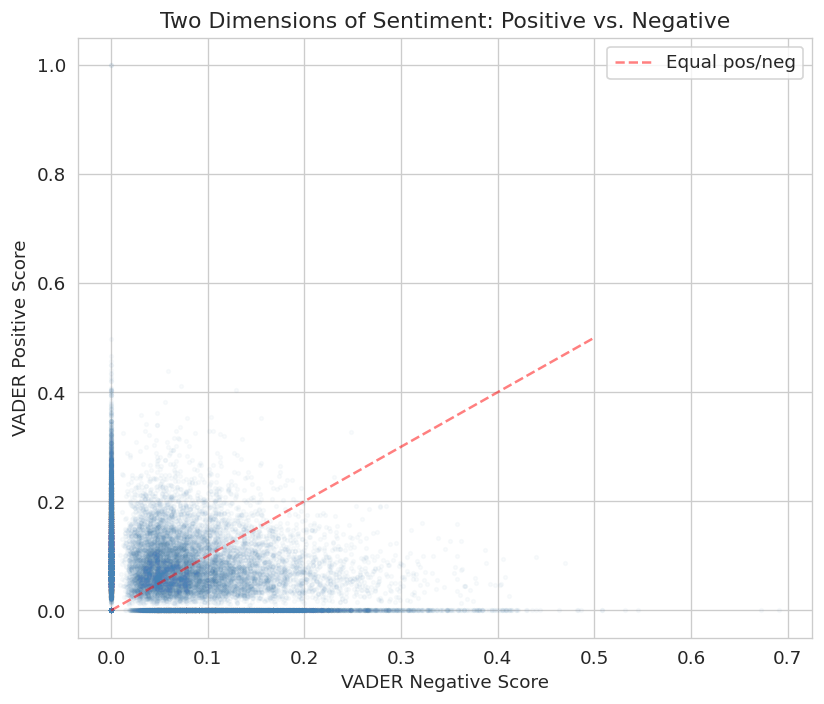

Most questions cluster near (0, 0) -- largely neutral.
Questions above the diagonal are more positive; below are more negative.


In [72]:
# Extension: Positive and negative scores as two dimensions
# Instead of relying on the single compound score, we can look at
# positive and negative scores separately

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(df["vader_neg"], df["vader_pos"], alpha=0.03, s=5, color="steelblue")
ax.set_xlabel("VADER Negative Score")
ax.set_ylabel("VADER Positive Score")
ax.set_title("Two Dimensions of Sentiment: Positive vs. Negative")
ax.plot([0, 0.5], [0, 0.5], color="red", linestyle="--", alpha=0.5, label="Equal pos/neg")
ax.legend()
plt.tight_layout()
plt.show()

print("Most questions cluster near (0, 0) -- largely neutral.")
print("Questions above the diagonal are more positive; below are more negative.")


**Discussion:** What might explain the patterns we observe?

- **Time trends** may reflect changing geopolitical tensions (e.g., US-China trade war, COVID-19, tensions over Taiwan or Hong Kong).
- **Spokesperson variation** partly reflects which years they served and what events dominated those periods.
- **News agency differences** may reflect editorial stances -- some agencies ask more confrontational questions than others.
- **Country-level sentiment** reveals which bilateral relationships generate the most negative press coverage.
- **Positive vs. negative as two dimensions** shows that most press conference questions are largely neutral, with only a minority showing strong positive or negative tone. Some questions contain both positive and negative elements simultaneously.
- Sentiment scores capture **tone**, not **substance** -- a question about a humanitarian crisis could score negative even if the journalist is sympathetic.


---
## Part B: Machine Learning Text Classification

### B.1 From Sentiment Scores to Classification

Dictionary-based sentiment gives us a **continuous score**. But sometimes we need a **binary label**: is this question "aggressive" or not? This is a **classification** problem.

We will define **"aggressive"** as questions whose `q_sentiment` score falls in the **bottom 25th percentile** -- the most negative questions in the corpus. This is a simplification, but it gives us a concrete label to work with.

In [73]:
# Create binary label: q_aggressive = 1 if q_sentiment <= 25th percentile
df_ml = df.dropna(subset=["q_sentiment", "question"]).copy()
threshold = df_ml["q_sentiment"].quantile(0.25)
df_ml["q_aggressive"] = (df_ml["q_sentiment"] <= threshold).astype(int)

print(f"Sentiment threshold (25th percentile): {threshold:.4f}")
print(f"\nClass distribution:")
print(df_ml["q_aggressive"].value_counts())
print(f"\nProportion aggressive: {df_ml['q_aggressive'].mean():.2%}")

Sentiment threshold (25th percentile): 1.4753

Class distribution:
q_aggressive
0    26509
1     8837
Name: count, dtype: int64

Proportion aggressive: 25.00%


The classes are imbalanced (~25% aggressive vs. ~75% non-aggressive) by construction. Keep this in mind when evaluating our classifier -- accuracy alone can be misleading when one class dominates.

### B.2 Prepare Features (X) and Labels (y)

For machine learning classification, we need:

- **X** = features (the text, represented as numbers). We will use the **Bag-of-Words** representation from Session 2.
- **y** = labels (`q_aggressive`, 0 or 1).

We will preprocess the text with spaCy (lemmatize, remove stopwords/punctuation/numbers) and then convert to a document-term matrix with `CountVectorizer`.

In [74]:
# Sample 20000 rows for speed (full dataset works but is slower)
df_sample = df_ml.sample(n=10000, random_state=42).reset_index(drop=True)
print(f"Working with {len(df_sample)} rows")
print(f"Class distribution in sample:")
print(df_sample["q_aggressive"].value_counts())

Working with 10000 rows
Class distribution in sample:
q_aggressive
0    7463
1    2537
Name: count, dtype: int64


In [75]:
# Tokenize questions with spaCy (same pipeline as Session 2)
nlp = spacy.load("en_core_web_sm", disable=["parser", "ner"])  # only need tokenizer + lemmatizer

# Domain-specific stopwords (same as Session 2)
domain_stopwords = {"china", "chinese", "say", "comment", "question", "report",
                    "country", "state", "government", "minister", "foreign",
                    "people", "spokesperson", "medium", "press", "conference",
                    "regard", "side", "note", "relate", "concern", "issue"}

def preprocess(text):
    """Lemmatize, remove stopwords, punctuation, numbers, short tokens, and domain stopwords."""
    doc = nlp(str(text))
    tokens = [
        token.lemma_.lower() for token in doc
        if not token.is_stop
        and not token.is_punct
        and not token.like_num
        and len(token.text) > 2
        and token.lemma_.lower() not in domain_stopwords
    ]
    return tokens

# Apply preprocessing
print("Preprocessing text with spaCy (this may take a minute)...")
df_sample["tokens"] = df_sample["question"].apply(preprocess)
print(f"Done. Example tokens: {df_sample['tokens'].iloc[0][:10]}")


Preprocessing text with spaCy (this may take a minute)...
Done. Example tokens: ['passage', 'bill', 'house', 'representatives', 'impact', 'phase', 'trade', 'deal', 'timeline']


In [76]:
# Build document-term matrix with CountVectorizer
# Since text is already tokenized, we pass an identity function as tokenizer
vectorizer = CountVectorizer(
    analyzer="word",
    tokenizer=lambda x: x,   # input is already a list of tokens
    preprocessor=lambda x: x, # no additional preprocessing
    min_df=10,                 # ignore terms that appear in fewer than 5 documents
    max_df=0.50               # ignore terms that appear in more than 50% of documents
)

X = vectorizer.fit_transform(df_sample["tokens"])
y = df_sample["q_aggressive"].values

print(f"Document-term matrix shape: {X.shape}")
print(f"  {X.shape[0]} documents, {X.shape[1]} unique terms")
print(f"Labels shape: {y.shape}")

Document-term matrix shape: (10000, 2246)
  10000 documents, 2246 unique terms
Labels shape: (10000,)


### Train/Test Split: Why?

A key goal of machine learning is **prediction** -- how well does the model perform on data it has **never seen** before?

To test this, we:
1. **Split** the data into two parts: training set (80%) and test set (20%)
2. **Train** the model using only the training set
3. **Evaluate** the model on the test set -- pretending we don't know the answers
4. **Compare** the model's predictions with the actual labels

Without splitting, the model could simply **memorize** the training data and appear to perform perfectly -- but fail on new data. This problem is called **overfitting**. The train/test split is our safeguard against it.


In [77]:
# Train/test split (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape:  {X_test.shape}")
print(f"y_train distribution: {np.bincount(y_train)}")
print(f"y_test distribution:  {np.bincount(y_test)}")


X_train shape: (8000, 2246)
X_test shape:  (2000, 2246)
y_train distribution: [5970 2030]
y_test distribution:  [1493  507]


### B.3 Train and Evaluate a Logistic Regression

Logistic regression is a simple, interpretable classifier that works well for text. It learns a weight for each word and combines them linearly to predict the probability that a question is "aggressive."

In [78]:
# Train logistic regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Predict on test set
y_pred_lr = lr.predict(X_test)

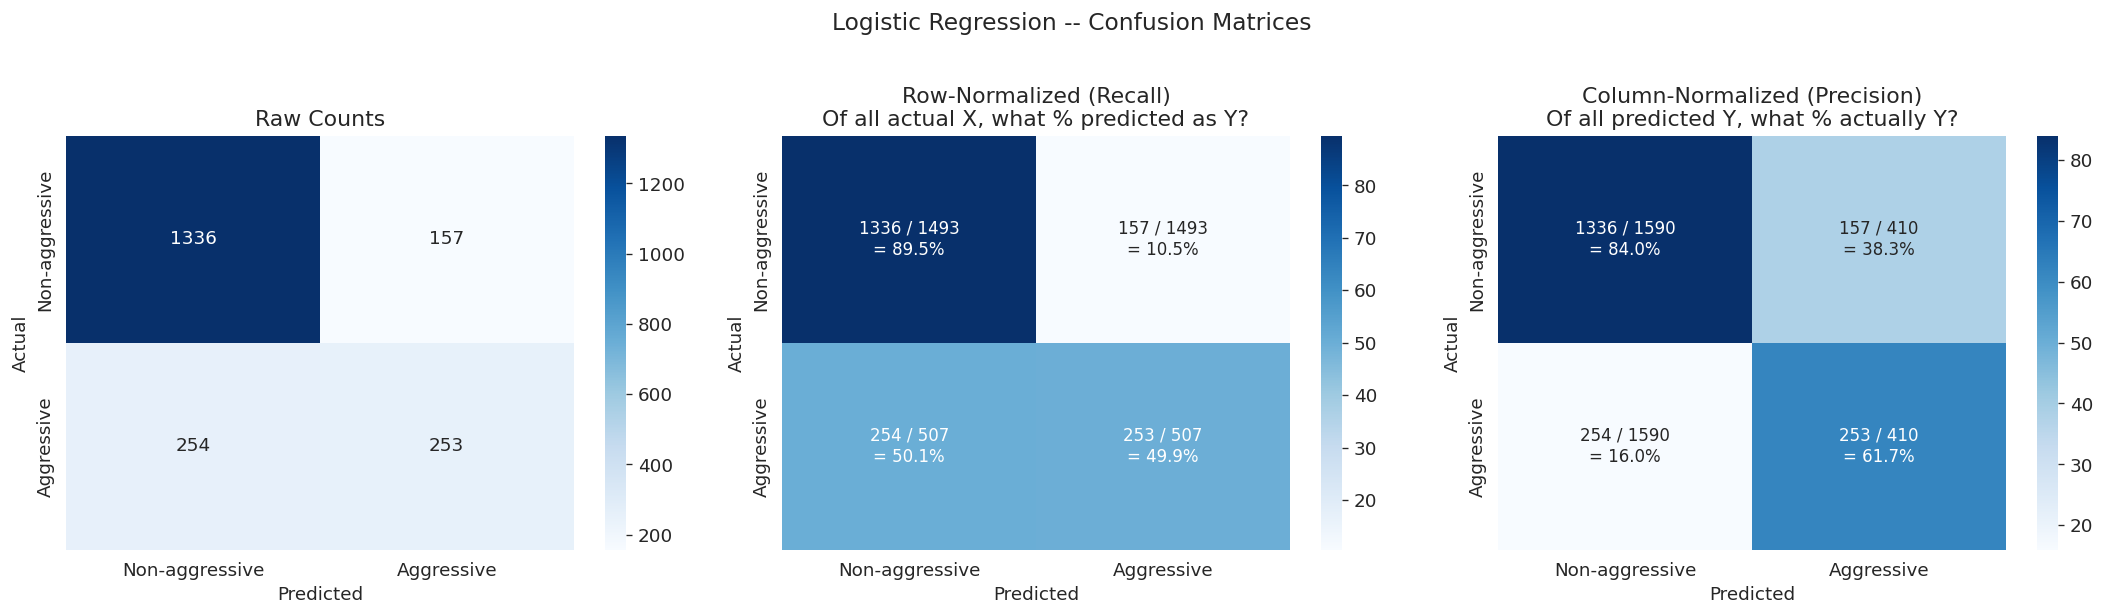

In [79]:
# Confusion matrices: raw counts, row-normalized (recall), column-normalized (precision)
cm_lr = metrics.confusion_matrix(y_test, y_pred_lr)
labels = ["Non-aggressive", "Aggressive"]

def plot_three_confusion_matrices(cm, title, cmap="Blues"):
    """Plot 3 confusion matrices side by side: raw, row-normalized, column-normalized.
    Normalized cells show the calculation (e.g., '1336 / 1493 = 89.5%')."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # (1) Raw counts
    sns.heatmap(cm, annot=True, fmt="d", cmap=cmap, ax=axes[0],
                xticklabels=labels, yticklabels=labels)
    axes[0].set_xlabel("Predicted")
    axes[0].set_ylabel("Actual")
    axes[0].set_title("Raw Counts")

    # (2) Row-normalized (Recall): each row sums to 100%
    cm_row = cm / cm.sum(axis=1, keepdims=True) * 100
    # Build annotation labels showing calculation
    row_annot = np.empty_like(cm, dtype=object)
    for r in range(cm.shape[0]):
        row_total = cm[r].sum()
        for c in range(cm.shape[1]):
            row_annot[r, c] = f"{cm[r,c]} / {row_total}\n= {cm_row[r,c]:.1f}%"
    sns.heatmap(cm_row, annot=row_annot, fmt="", cmap=cmap, ax=axes[1],
                xticklabels=labels, yticklabels=labels, annot_kws={"size": 10})
    axes[1].set_xlabel("Predicted")
    axes[1].set_ylabel("Actual")
    axes[1].set_title("Row-Normalized (Recall)\nOf all actual X, what % predicted as Y?")

    # (3) Column-normalized (Precision): each column sums to 100%
    cm_col = cm / cm.sum(axis=0, keepdims=True) * 100
    col_annot = np.empty_like(cm, dtype=object)
    for r in range(cm.shape[0]):
        for c in range(cm.shape[1]):
            col_total = cm[:, c].sum()
            col_annot[r, c] = f"{cm[r,c]} / {col_total}\n= {cm_col[r,c]:.1f}%"
    sns.heatmap(cm_col, annot=col_annot, fmt="", cmap=cmap, ax=axes[2],
                xticklabels=labels, yticklabels=labels, annot_kws={"size": 10})
    axes[2].set_xlabel("Predicted")
    axes[2].set_ylabel("Actual")
    axes[2].set_title("Column-Normalized (Precision)\nOf all predicted Y, what % actually Y?")

    plt.suptitle(title, fontsize=14, y=1.02)
    plt.tight_layout()
    plt.show()

plot_three_confusion_matrices(cm_lr, "Logistic Regression -- Confusion Matrices", cmap="Blues")


**Reading the three confusion matrices:**

- **Raw Counts** (left): how many questions fall into each cell. Gives the overall volume.
- **Row-Normalized / Recall** (middle): each row sums to 100%. Read row by row: *"Of all truly aggressive questions, what percentage did the model correctly identify?"* The diagonal shows recall for each class.
- **Column-Normalized / Precision** (right): each column sums to 100%. Read column by column: *"Of all questions the model labeled aggressive, what percentage actually were aggressive?"* The diagonal shows precision for each class.


In [80]:
# Classification report
print(metrics.classification_report(y_test, y_pred_lr, target_names=["Non-aggressive", "Aggressive"]))

                precision    recall  f1-score   support

Non-aggressive       0.84      0.89      0.87      1493
    Aggressive       0.62      0.50      0.55       507

      accuracy                           0.79      2000
     macro avg       0.73      0.70      0.71      2000
  weighted avg       0.78      0.79      0.79      2000



**A note on evaluation metrics: why report both classes?**

In many research papers, you'll see a single F1 score, precision, and recall reported. This is typically the metrics for the **positive class** only (in our case, "Aggressive") -- because that's the rare, interesting class that's harder to predict.

scikit-learn's `classification_report` shows metrics for **both** classes, plus two summary rows:
- **macro avg**: unweighted mean of both classes (treats both equally)
- **weighted avg**: weighted by class size (gives more weight to the larger class)

Showing both classes is more transparent. The majority class ("Non-aggressive") is usually easy to classify, so its high metrics can be misleading if reported alone. Always check the **minority class** metrics -- that's where classifiers struggle.


**Understanding the metrics:**

| Metric | Meaning in this context |
|--------|------------------------|
| **Accuracy** | What percentage of all predictions were correct? |
| **Precision** | Of all questions we labeled "aggressive," what percentage actually were? (Low precision = too many false alarms.) |
| **Recall** | Of all truly aggressive questions, what percentage did we catch? (Low recall = we missed many aggressive questions.) |
| **F1** | Harmonic mean of precision and recall -- a single number balancing both concerns. |

<!-- Add some text to explain why we need the different metrics: 
balancing false positive and false negative.
 -->

 <!-- Add some text to explain what values of accuracy, precision, recall, and F1 we typically aim for. Is there a number we are targeting at? Do some research. I would also add that the number we target dependent on how challenging the task is.
 -->

### B.4 Interpret the Model

A major advantage of logistic regression is **interpretability**. Each feature (word) has a coefficient. Positive coefficients push toward the "aggressive" label; negative coefficients push toward "non-aggressive."

In [81]:
# Get feature names and coefficients
feature_names = vectorizer.get_feature_names_out()
coefs = lr.coef_[0]

coef_df = pd.DataFrame({"word": feature_names, "coefficient": coefs})
coef_df = coef_df.sort_values("coefficient", ascending=False)

print("Top 10 words predicting AGGRESSIVE:")
print(coef_df.head(10).to_string(index=False))
print("\nTop 10 words predicting NON-AGGRESSIVE:")
print(coef_df.tail(10).to_string(index=False))

Top 10 words predicting AGGRESSIVE:
      word  coefficient
      fail     1.850892
    resign     1.834104
   protest     1.776419
accusation     1.769560
   worried     1.751787
    cancel     1.732858
      veto     1.639828
   boycott     1.634940
  threaten     1.617911
  negative     1.595537

Top 10 words predicting NON-AGGRESSIVE:
          word  coefficient
           wto    -1.343302
           zte    -1.380243
     negotiate    -1.405434
        future    -1.432100
         brief    -1.545437
          sign    -1.600275
       defence    -1.637778
  successfully    -1.752924
           hop    -2.020757
opening_remark    -2.641499


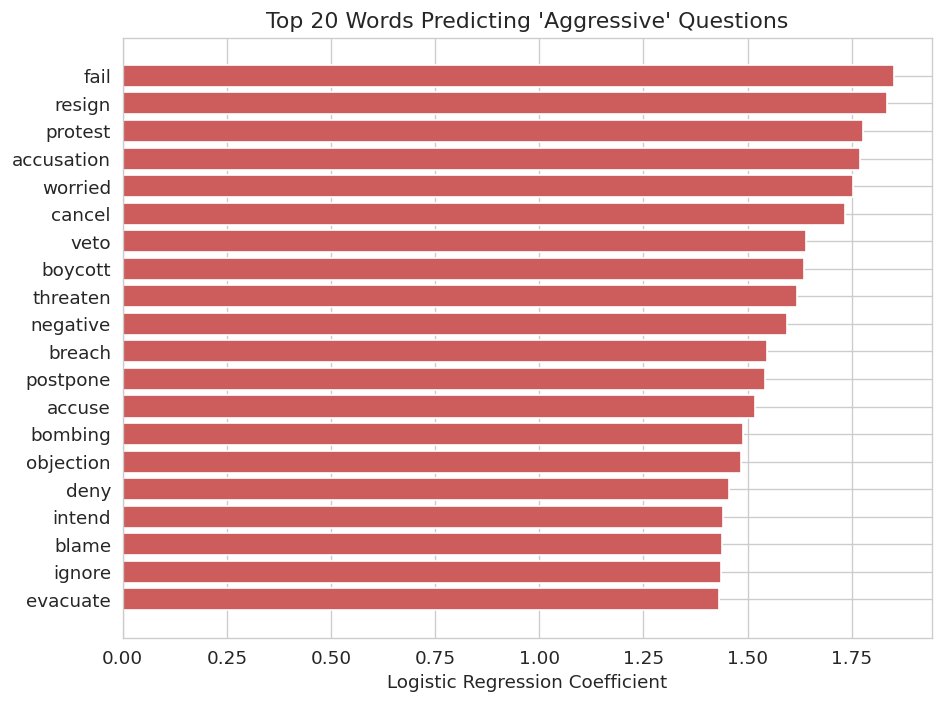

In [82]:
# Plot top 20 words predicting aggressive questions
top_aggressive = coef_df.head(20).sort_values("coefficient")

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_aggressive["word"], top_aggressive["coefficient"], color="indianred", edgecolor="white")
ax.set_xlabel("Logistic Regression Coefficient")
ax.set_title("Top 20 Words Predicting 'Aggressive' Questions")
plt.tight_layout()
plt.show()

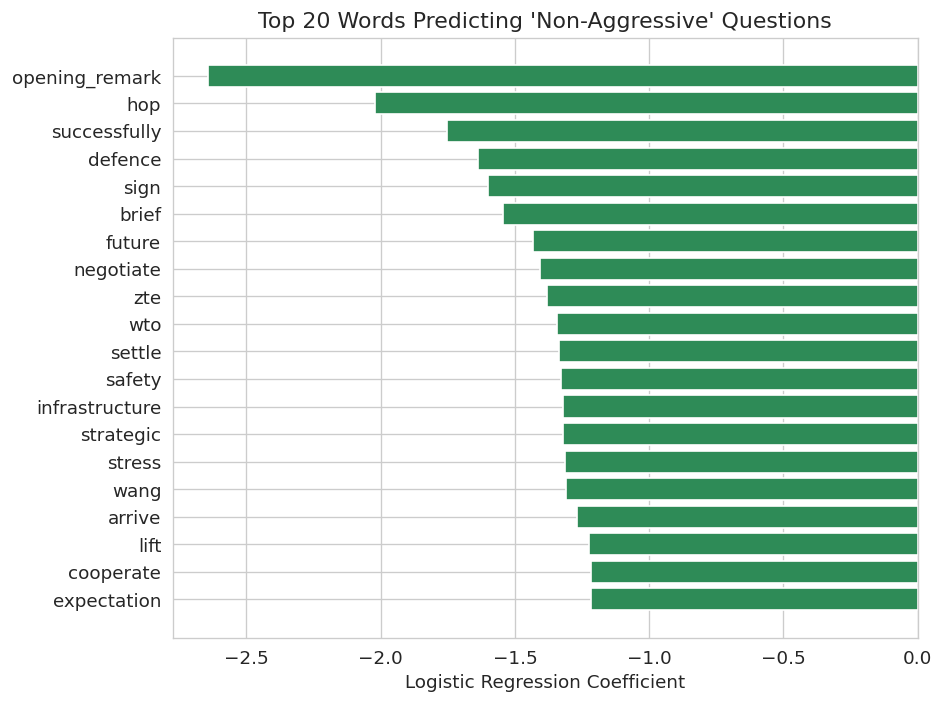

In [83]:
# Plot top 20 words predicting non-aggressive questions
top_nonaggressive = coef_df.tail(20).sort_values("coefficient", ascending=False)

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top_nonaggressive["word"], top_nonaggressive["coefficient"], color="seagreen", edgecolor="white")
ax.set_xlabel("Logistic Regression Coefficient")
ax.set_title("Top 20 Words Predicting 'Non-Aggressive' Questions")
plt.tight_layout()
plt.show()

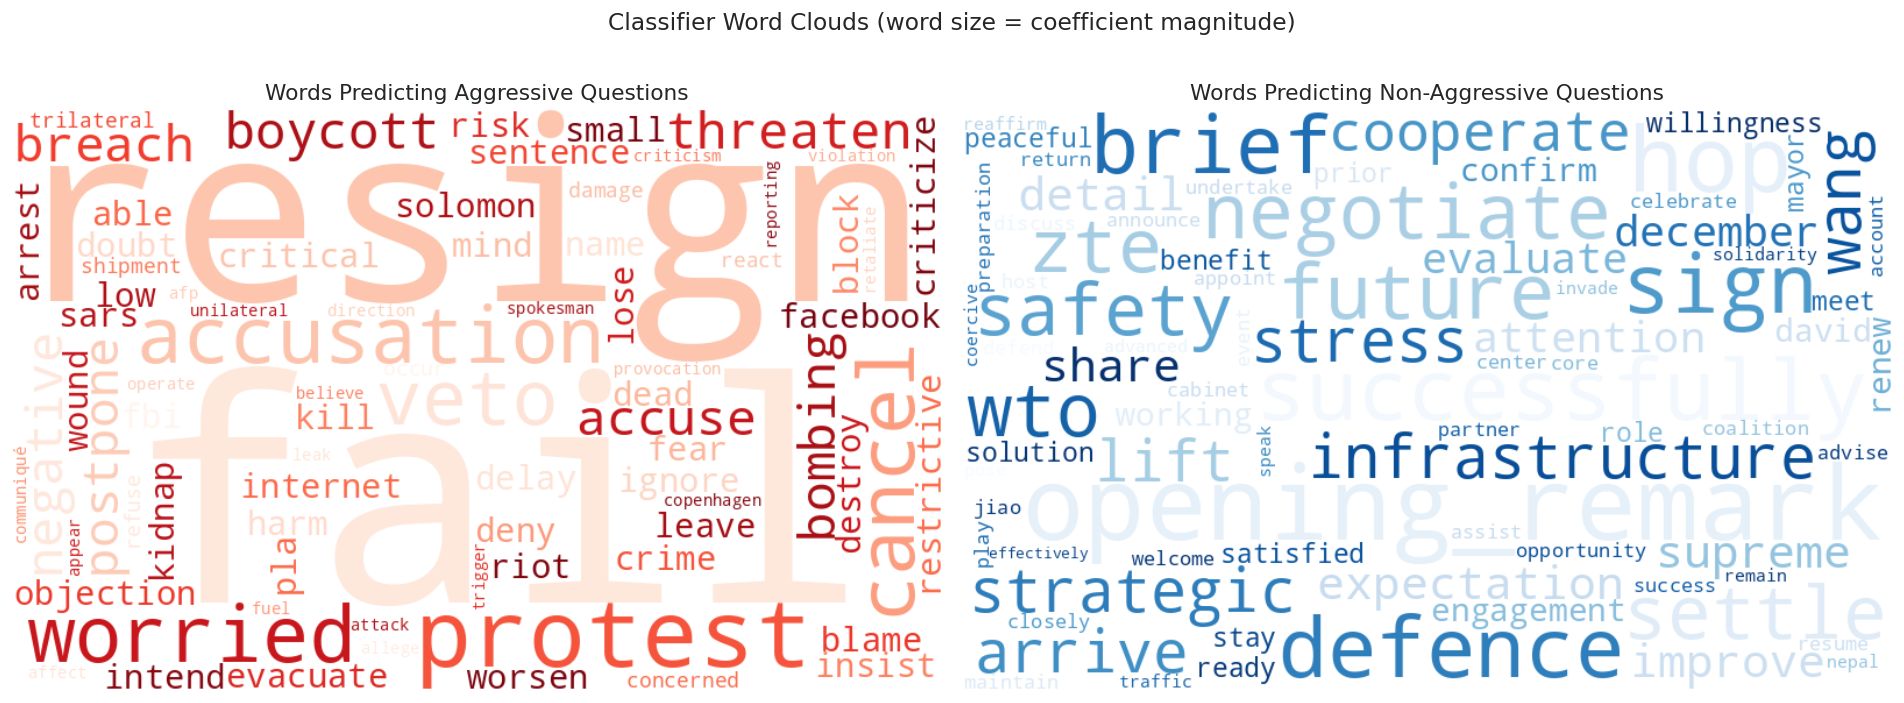

In [84]:
from wordcloud import WordCloud

# Get feature names and logistic regression coefficients
feature_names = vectorizer.get_feature_names_out()
coefs = lr.coef_[0]

# Separate positive (aggressive) and negative (non-aggressive) coefficients
aggressive_words = {feature_names[i]: coefs[i] for i in range(len(coefs)) if coefs[i] > 0}
nonaggressive_words = {feature_names[i]: abs(coefs[i]) for i in range(len(coefs)) if coefs[i] < 0}

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Word cloud for aggressive-predicting words
wc_agg = WordCloud(width=800, height=500, background_color="white",
                   colormap="Reds", random_state=42, max_words=80)
wc_agg.generate_from_frequencies(aggressive_words)
axes[0].imshow(wc_agg, interpolation="bilinear")
axes[0].set_title("Words Predicting Aggressive Questions", fontsize=13)
axes[0].axis("off")

# Word cloud for non-aggressive-predicting words
wc_nonagg = WordCloud(width=800, height=500, background_color="white",
                      colormap="Blues", random_state=42, max_words=80)
wc_nonagg.generate_from_frequencies(nonaggressive_words)
axes[1].imshow(wc_nonagg, interpolation="bilinear")
axes[1].set_title("Words Predicting Non-Aggressive Questions", fontsize=13)
axes[1].axis("off")

plt.suptitle("Classifier Word Clouds (word size = coefficient magnitude)", fontsize=14, y=1.01)
plt.tight_layout()
plt.show()


**Discussion:** Do these words make substantive sense? Words associated with aggression likely relate to contentious geopolitical topics (e.g., sanctions, military, human rights), while non-aggressive words may relate to routine diplomacy (e.g., visit, cooperation, welcome). This kind of face-validity check is essential when using ML classifiers for social science research.

### B.5 Try Another Model: Random Forest

Random forests are an ensemble method that builds many decision trees and averages their predictions. They can capture non-linear relationships but are less interpretable than logistic regression.

In [85]:
# Train random forest
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

# Predict on test set
y_pred_rf = rf.predict(X_test)

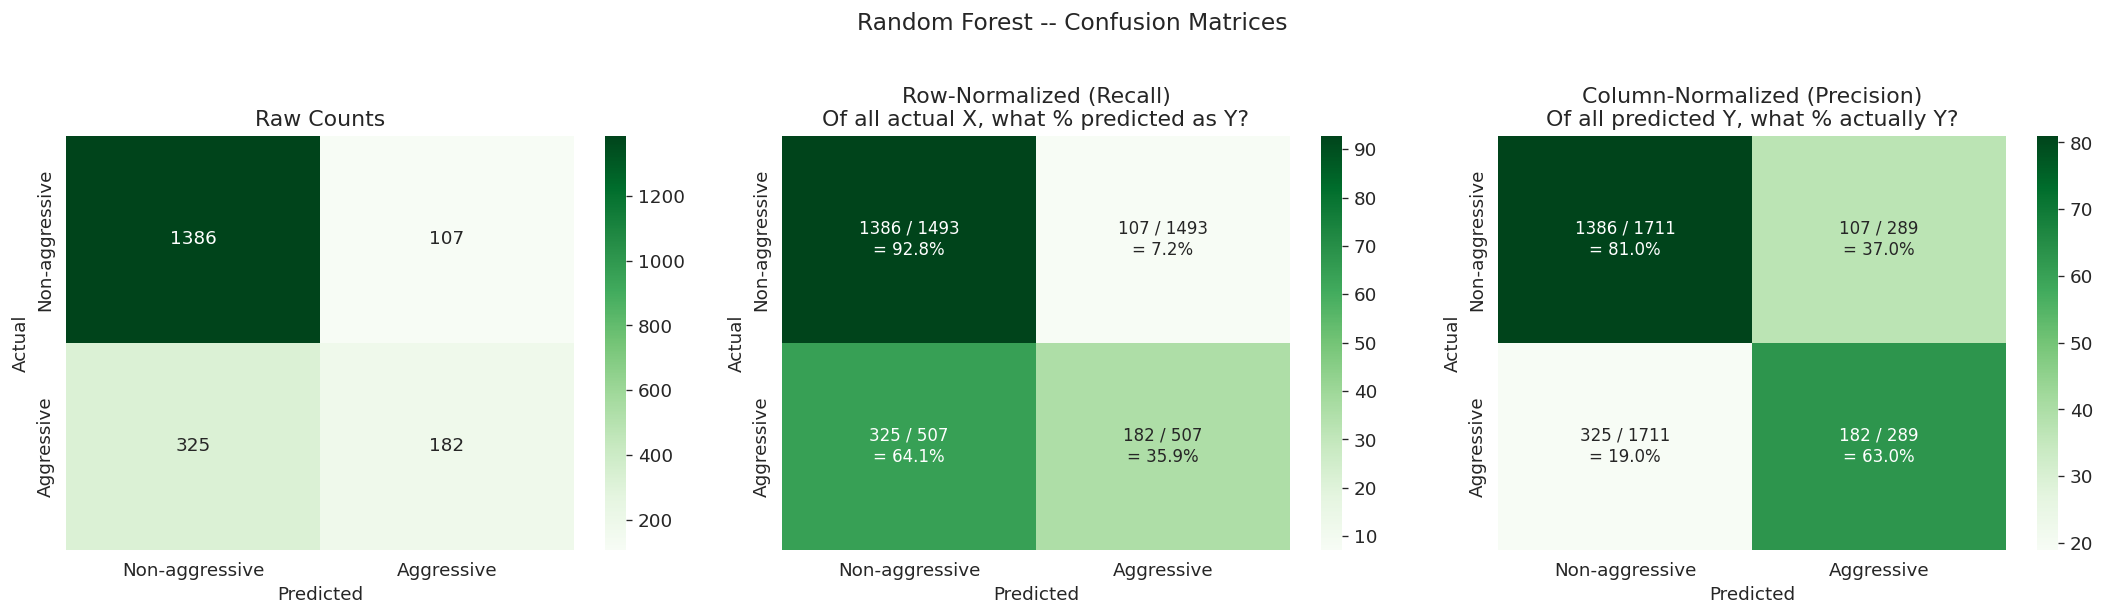

Random Forest -- Classification Report
                precision    recall  f1-score   support

Non-aggressive       0.81      0.93      0.87      1493
    Aggressive       0.63      0.36      0.46       507

      accuracy                           0.78      2000
     macro avg       0.72      0.64      0.66      2000
  weighted avg       0.76      0.78      0.76      2000



In [86]:
# Random Forest confusion matrices
cm_rf = metrics.confusion_matrix(y_test, y_pred_rf)
plot_three_confusion_matrices(cm_rf, "Random Forest -- Confusion Matrices", cmap="Greens")

print("Random Forest -- Classification Report")
print(metrics.classification_report(y_test, y_pred_rf, target_names=["Non-aggressive", "Aggressive"]))


In [87]:
# Side-by-side comparison of the two models
comparison = pd.DataFrame({
    "Metric": ["Accuracy", "Precision (Aggressive)", "Recall (Aggressive)", "F1 (Aggressive)"],
    "Logistic Regression": [
        metrics.accuracy_score(y_test, y_pred_lr),
        metrics.precision_score(y_test, y_pred_lr),
        metrics.recall_score(y_test, y_pred_lr),
        metrics.f1_score(y_test, y_pred_lr)
    ],
    "Random Forest": [
        metrics.accuracy_score(y_test, y_pred_rf),
        metrics.precision_score(y_test, y_pred_rf),
        metrics.recall_score(y_test, y_pred_rf),
        metrics.f1_score(y_test, y_pred_rf)
    ]
})

# Format as percentages
comparison["Logistic Regression"] = comparison["Logistic Regression"].map("{:.1%}".format)
comparison["Random Forest"] = comparison["Random Forest"].map("{:.1%}".format)
print(comparison.to_string(index=False))

                Metric Logistic Regression Random Forest
              Accuracy               79.5%         78.4%
Precision (Aggressive)               61.7%         63.0%
   Recall (Aggressive)               49.9%         35.9%
       F1 (Aggressive)               55.2%         45.7%


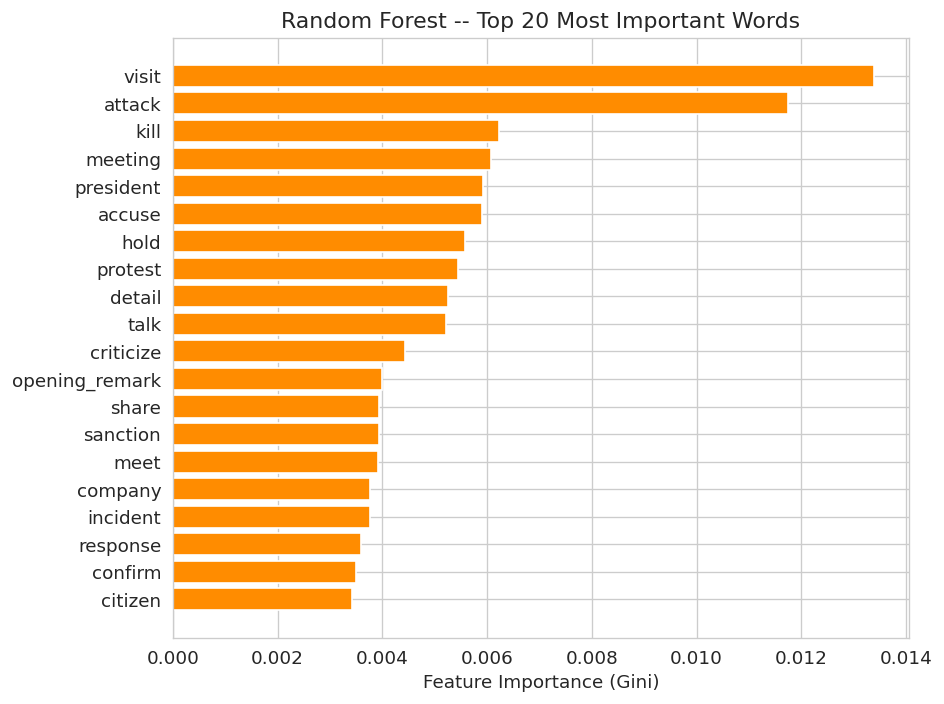

In [88]:
# Top 20 feature importances from random forest
importances = rf.feature_importances_
imp_df = pd.DataFrame({"word": feature_names, "importance": importances})
imp_df = imp_df.sort_values("importance", ascending=False)

top20_rf = imp_df.head(20).sort_values("importance")

fig, ax = plt.subplots(figsize=(8, 6))
ax.barh(top20_rf["word"], top20_rf["importance"], color="darkorange", edgecolor="white")
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title("Random Forest -- Top 20 Most Important Words")
plt.tight_layout()
plt.show()

Note that random forest feature importances do not tell us the **direction** of the effect (aggressive vs. non-aggressive) -- only that the word was useful for splitting. This is a trade-off: random forests may be more accurate, but logistic regression coefficients are more interpretable.

### B.6 Addressing Class Imbalance

Looking at the results above, the classifier performs much worse on the **Aggressive** class (low recall and F1) compared to the **Non-aggressive** class. Why?

Our dataset is **imbalanced**: ~75% non-aggressive vs. ~25% aggressive. The model learns to predict the majority class more often because that minimizes overall error. But this means it misses many aggressive questions.

**Solutions:**
- **Upsampling:** Duplicate examples from the minority class (aggressive) to balance the training data
- **Downsampling:** Remove examples from the majority class (non-aggressive) to balance the training data
- **Class weights:** Tell the model to penalize mistakes on the minority class more heavily

Let's try all three and compare.


In [89]:
from sklearn.utils import resample

X_train_dense = X_train.toarray()
majority_idx = np.where(y_train == 0)[0]
minority_idx = np.where(y_train == 1)[0]
print(f"Original: majority={len(majority_idx)}, minority={len(minority_idx)}")

# --- Method 1: Upsampling (duplicate minority to match majority) ---
minority_up = resample(minority_idx, replace=True,
                       n_samples=len(majority_idx), random_state=42)
up_idx = np.concatenate([majority_idx, minority_up])
X_train_up = X_train_dense[up_idx]
y_train_up = y_train[up_idx]
print(f"Upsampled: majority={np.sum(y_train_up==0)}, minority={np.sum(y_train_up==1)}")

model_upsample = LogisticRegression(max_iter=1000, random_state=42)
model_upsample.fit(X_train_up, y_train_up)
y_pred_upsample = model_upsample.predict(X_test)

# --- Method 2: Downsampling (remove majority to match minority) ---
majority_down = resample(majority_idx, replace=False,
                         n_samples=len(minority_idx), random_state=42)
down_idx = np.concatenate([majority_down, minority_idx])
X_train_down = X_train_dense[down_idx]
y_train_down = y_train[down_idx]
print(f"Downsampled: majority={np.sum(y_train_down==0)}, minority={np.sum(y_train_down==1)}")

model_downsample = LogisticRegression(max_iter=1000, random_state=42)
model_downsample.fit(X_train_down, y_train_down)
y_pred_downsample = model_downsample.predict(X_test)

# --- Method 3: Class Weighting ---
model_weighted = LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")
model_weighted.fit(X_train, y_train)
y_pred_weighted = model_weighted.predict(X_test)

# --- Print all classification reports ---
for name, y_pred in [("Original (Imbalanced)", y_pred_lr),
                      ("Upsampled", y_pred_upsample),
                      ("Downsampled", y_pred_downsample),
                      ("Class Weight = Balanced", y_pred_weighted)]:
    print(f"--- {name} ---")
    print(metrics.classification_report(y_test, y_pred, target_names=["Non-aggressive", "Aggressive"]))


Original: majority=5970, minority=2030
Upsampled: majority=5970, minority=5970
Downsampled: majority=2030, minority=2030
--- Original (Imbalanced) ---
                precision    recall  f1-score   support

Non-aggressive       0.84      0.89      0.87      1493
    Aggressive       0.62      0.50      0.55       507

      accuracy                           0.79      2000
     macro avg       0.73      0.70      0.71      2000
  weighted avg       0.78      0.79      0.79      2000

--- Upsampled ---
                precision    recall  f1-score   support

Non-aggressive       0.87      0.82      0.84      1493
    Aggressive       0.54      0.63      0.59       507

      accuracy                           0.77      2000
     macro avg       0.71      0.73      0.71      2000
  weighted avg       0.79      0.77      0.78      2000

--- Downsampled ---
                precision    recall  f1-score   support

Non-aggressive       0.89      0.76      0.82      1493
    Aggressive      

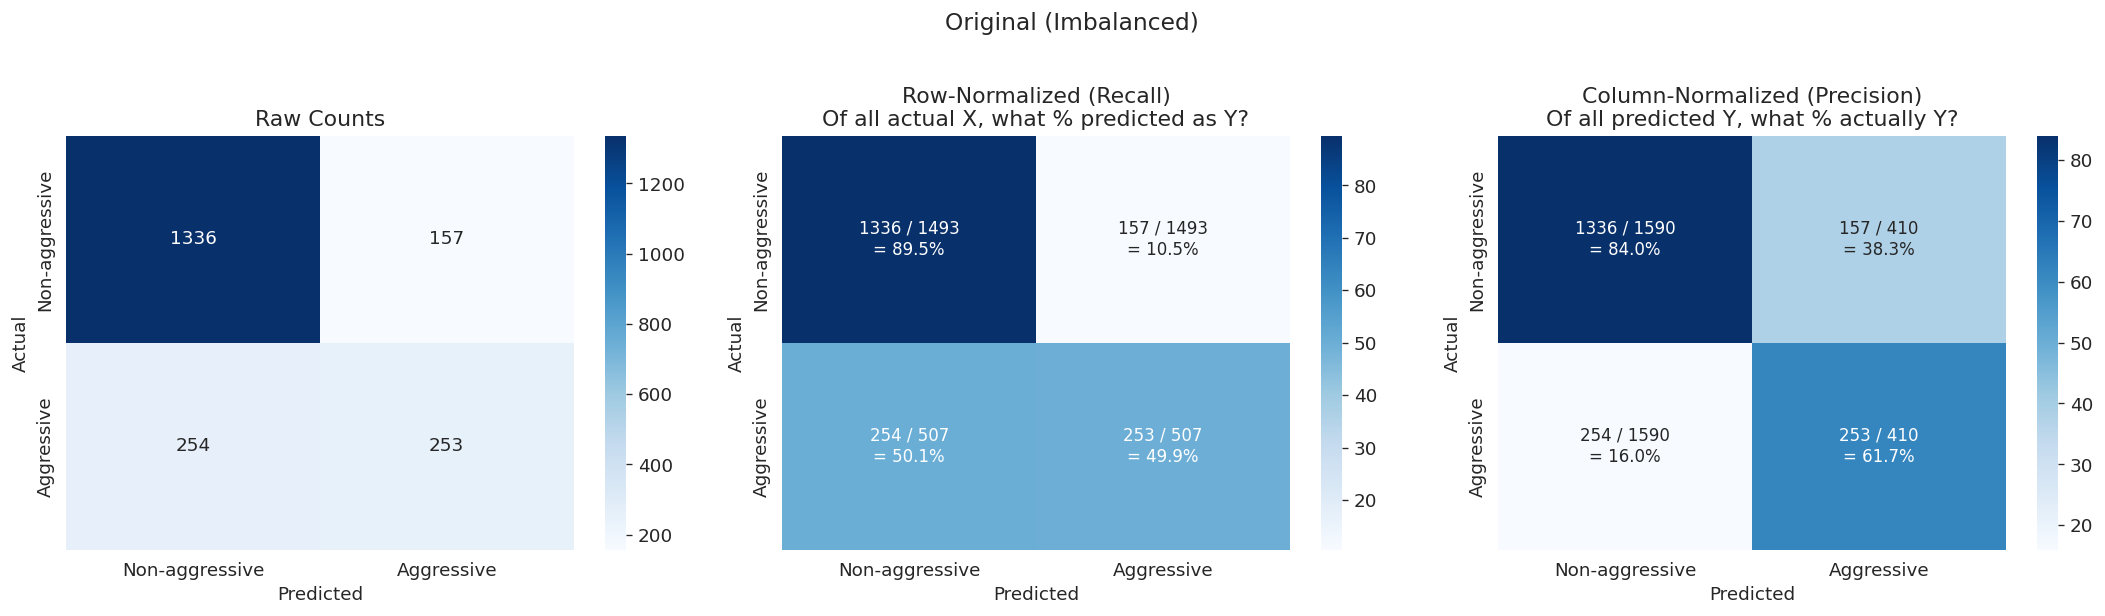

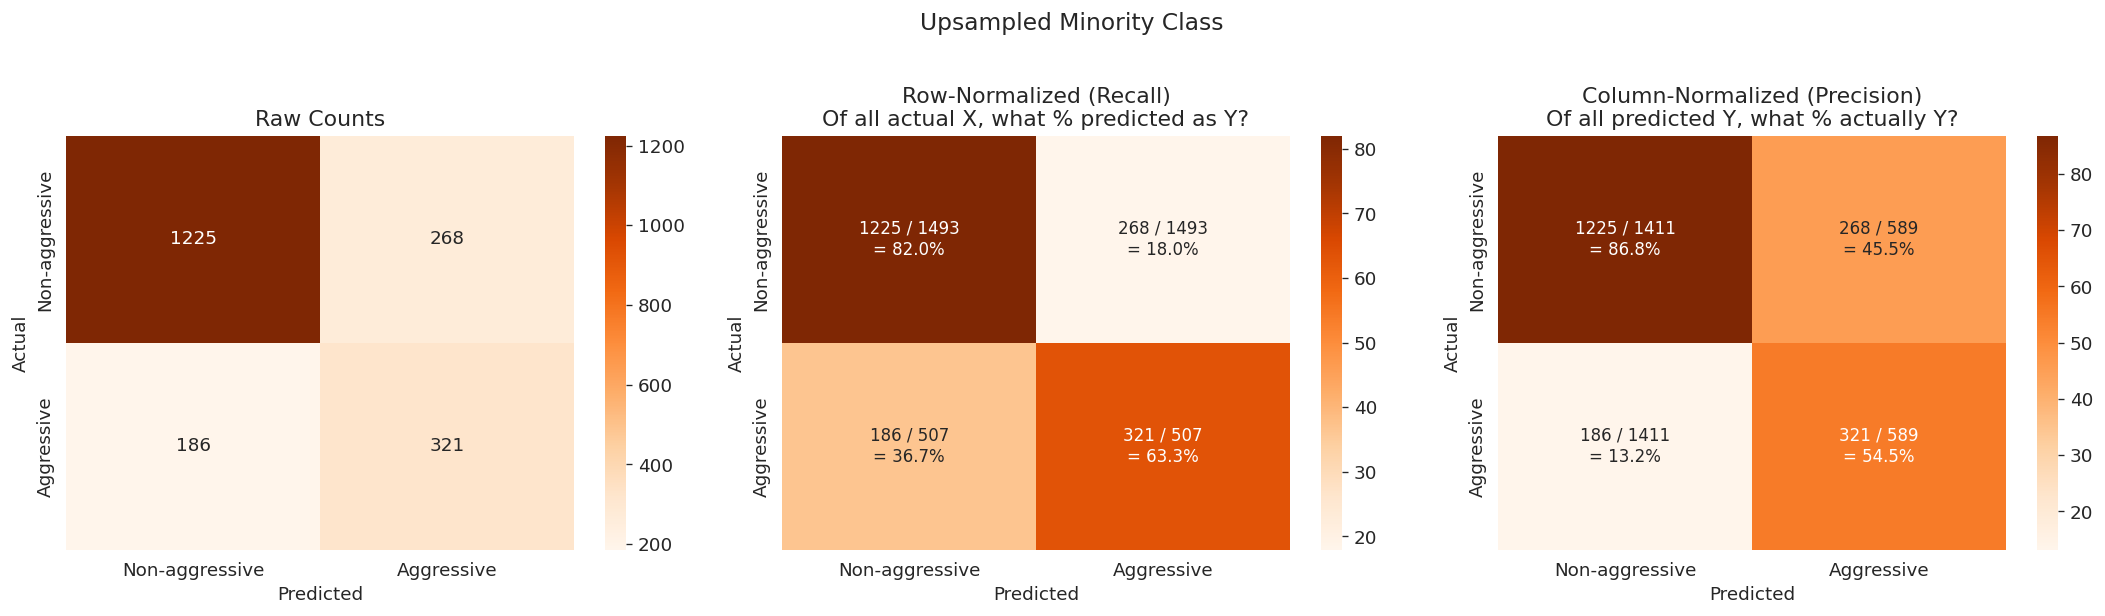

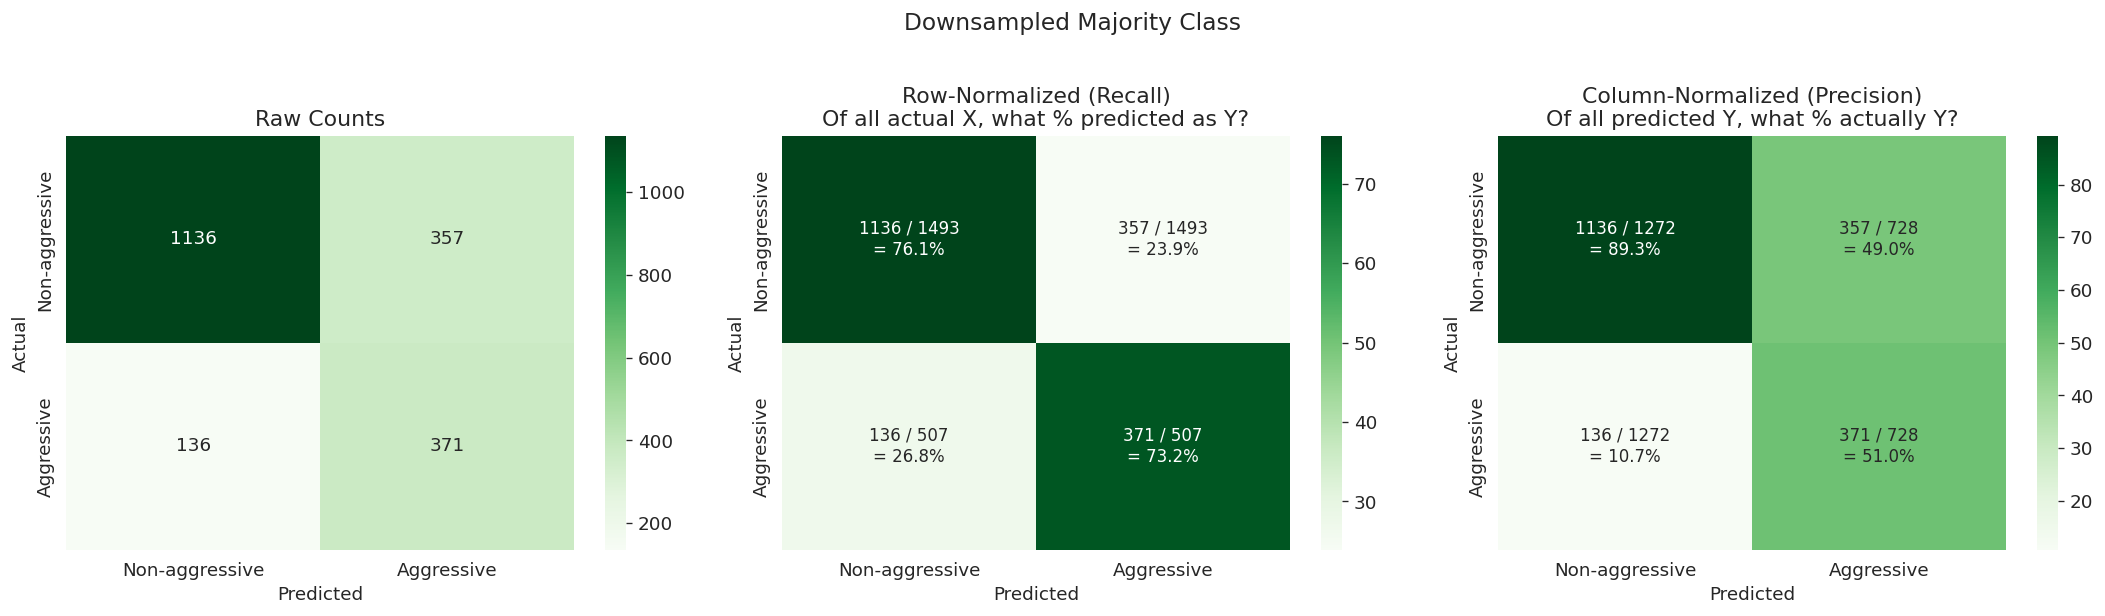

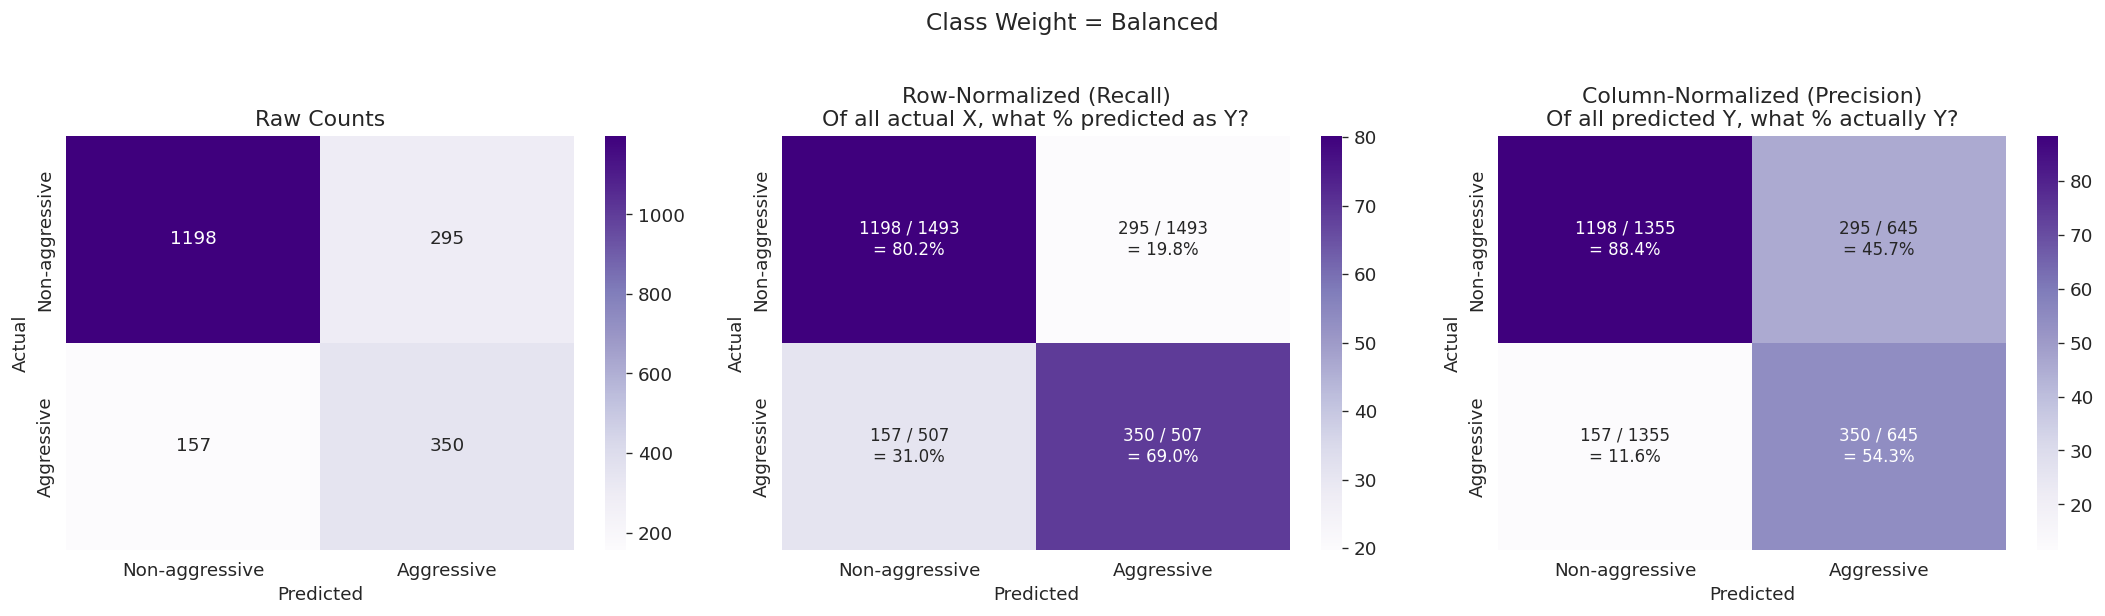

In [90]:
# Confusion matrices for all four approaches
cm_orig = metrics.confusion_matrix(y_test, y_pred_lr)
cm_up = metrics.confusion_matrix(y_test, y_pred_upsample)
cm_down = metrics.confusion_matrix(y_test, y_pred_downsample)
cm_wt = metrics.confusion_matrix(y_test, y_pred_weighted)

plot_three_confusion_matrices(cm_orig, "Original (Imbalanced)", cmap="Blues")
plot_three_confusion_matrices(cm_up, "Upsampled Minority Class", cmap="Oranges")
plot_three_confusion_matrices(cm_down, "Downsampled Majority Class", cmap="Greens")
plot_three_confusion_matrices(cm_wt, "Class Weight = Balanced", cmap="Purples")


**Discussion: Comparing Four Approaches**

Compare the row-normalized (recall) confusion matrices:

- **Original:** High recall for Non-aggressive, low recall for Aggressive. The model is biased toward the majority class.
- **Upsampled:** Recall for Aggressive improves -- we catch more truly aggressive questions. But precision may drop (more false alarms). Training set is larger (duplicated data).
- **Downsampled:** Similar effect to upsampling, but training set is smaller (data thrown away). Can hurt performance if the dataset is small, but with 35K rows we can afford it.
- **Weighted:** Similar effect to resampling approaches, achieved by internally adjusting the loss function. The most convenient -- just one parameter (`class_weight="balanced"`), no data manipulation needed.

All three methods address the same problem from different angles. In practice, `class_weight="balanced"` is the easiest starting point.


### B.7 Other Classification Models

We used Logistic Regression and Random Forest in this session. But scikit-learn offers many more classification models -- and they all follow the **same workflow**:

```python
model = SomeModel()       # initialize
model.fit(X_train, y_train)  # train
y_pred = model.predict(X_test)  # predict
```

The key differences are in **how** they learn patterns and **how interpretable** their results are.

| Model | sklearn Command | How It Works | Interpretability |
|-------|----------------|--------------|------------------|
| **Logistic Regression** | `LogisticRegression()` | Linear decision boundary based on word weights | High -- coefficients show each word's effect |
| **Decision Tree** | `DecisionTreeClassifier()` | Splits data by one feature at a time (like a flowchart) | High -- can visualize the full tree |
| **Random Forest** | `RandomForestClassifier()` | Ensemble of many decision trees, majority vote | Medium -- feature importances, but no direction |
| **Gradient Boosting** | `GradientBoostingClassifier()` | Ensemble of trees built sequentially, each correcting the last | Medium -- feature importances |
| **XGBoost** | `XGBClassifier()` (xgboost library) | Optimized gradient boosting, very popular in competitions | Medium -- feature importances |
| **Support Vector Machine** | `SVC()` | Finds the optimal boundary (hyperplane) between classes | Low -- hard to interpret in high dimensions |
| **Naive Bayes** | `MultinomialNB()` | Assumes words are independent, uses Bayes' theorem | Medium -- word probabilities per class |
| **k-Nearest Neighbors** | `KNeighborsClassifier()` | Classifies based on the most similar training examples | Low -- no global model, just similarity |
| **Neural Network (MLP)** | `MLPClassifier()` | Multiple layers of learned transformations | Low -- black box |

**Key insight:** As models get more powerful (bottom of the table), they tend to become less interpretable. This is known as the **accuracy-interpretability trade-off**. For political science research, interpretability often matters as much as accuracy -- you need to explain *why* the model made a prediction.


### B.8 The Bridge to LLMs

What we just did required three things:

1. **Manual text preprocessing** -- tokenization, lemmatization, stopword removal.
2. **Feature engineering** -- choosing Bag-of-Words, setting min_df/max_df parameters.
3. **Labeled training data** -- we needed pre-existing sentiment scores to create our `q_aggressive` label.

In **Sessions 4--5**, we will see how Large Language Models (LLMs) can perform sentiment analysis and text classification with just a **natural language prompt** -- no feature engineering, no training data, and often no preprocessing.

But traditional ML classifiers have important advantages:

- **Speed**: once trained, they classify thousands of documents per second.
- **Transparency**: logistic regression coefficients tell you exactly *why* the model made a prediction.
- **Reproducibility**: the same model + data always gives the same result. LLM outputs can vary.
- **Cost**: ML classifiers run locally with no API fees.

The best approach depends on your research question, your budget, and how much labeled data you have.

---
## Your Turn

**Exercise 1: Sentiment of answers to aggressive questions**

Apply VADER sentiment to the `answer` column. Do spokespeople respond more negatively to aggressive questions?

Steps:
1. Compute VADER compound scores for the `answer` column.
2. Merge with the `q_aggressive` label.
3. Group by `q_aggressive` and compare mean answer sentiment.

**Exercise 2: TF-IDF features**

We used raw word counts (CountVectorizer) as features. Try using **TF-IDF** weights instead (swap `CountVectorizer` for `TfidfVectorizer` from sklearn). Does classification performance improve?

**Exercise 3: Vibe coding -- try other classification models**

Use the table in B.7 as a reference. Give the following prompts to an AI coding assistant (e.g., Claude, ChatGPT, GitHub Copilot):

> "Using the same X_train, X_test, y_train, y_test from this notebook, train a **Gradient Boosting classifier** (`GradientBoostingClassifier` from sklearn) to predict aggressive questions. Evaluate with a classification report and confusion matrix. Compare performance with the logistic regression results."

> "Train **all of the following models** on the same data: Logistic Regression, Decision Tree, Random Forest, Gradient Boosting, SVM, Naive Bayes, and MLP. For each, compute accuracy, precision, recall, and F1 for the Aggressive class. Display the results in a single comparison table, sorted by F1 score."

> "Build a classifier that predicts **which spokesperson** gave the answer, using the answer text as input. Try at least 3 different models. Which model performs best? Which words are most distinctive for each spokesperson?"
